In [28]:
from matplotlib import pyplot as plt
from matplotlib.colors import to_rgb
import numpy as np

In [46]:
def _blend_color(c0, c1, t):
    return tuple(c0[i] * (1 - t) + c1[i] * t for i in range(3))

def fill_gradient(ax, x, y, color_low, color_high, steps=200):
    """Fill under a curve with a horizontal gradient along x."""
    c0 = to_rgb(color_low)
    c1 = to_rgb(color_high)
    for i in range(len(x) - 1):
        t = i / (len(x) - 2) if len(x) > 2 else 0
        color = _blend_color(c0, c1, t)
        ax.fill_between(x[i:i+2], y[i:i+2], color=color, alpha=1, zorder=1)

def add_marker(ax, subfigure_marker):
    ax.text(
        0.035,
        1.02,
        subfigure_marker,
        transform=ax.transAxes,
        ha='center',
        va='center',
        fontsize=11,
        fontweight='bold',
        bbox={
            'boxstyle': 'circle,pad=0.35',
            'facecolor': 'white',
            'edgecolor': 'black',
            'linewidth': 1
        }
    )

def plot_curve(
    ax,
    x,
    y,
    title,
    fill_color="gray",
    line_color="steelblue",
    gradient=False,
    grad_high="white",
    show_labels=False,
    high_label=None,
    low_label=None,
    subfigure_marker=None
):
    ax.set_aspect(10, adjustable='box')
    ax.set_xticks([])
    ax.set_yticks([])
    for side in ['top', 'right', 'left', 'bottom']:
        ax.spines[side].set_visible(False)
    ax.axhline(0, color='black', linewidth=1, zorder=0)
    if gradient:
        fill_gradient(ax, x, y, fill_color, grad_high)
    else:
        ax.fill_between(x, y, color=fill_color, alpha=0.5, zorder=1)
    ax.plot(x, y, color=line_color, linewidth=2, antialiased=True, zorder=3)
    ax.set_title(title)
    if subfigure_marker is not None:
        add_marker(ax, subfigure_marker)

    ax.tick_params(bottom=False, labelbottom=False, left=False, labelleft=False)
    ax.set_ylim(-0.05, max(1.05, np.max(y) * 1.05))
    ax.set_xlim(min(x), max(x))
    if show_labels:
        if high_label:
            ax.text(
                min(x) + 0.7,
                0.9,
                high_label,
                ha='left',
                va='center',
                fontsize=10
            )
        if low_label:
            ax.text(
                min(x) + 0.7,
                0.1,
                low_label,
                ha='left',
                va='center',
                fontsize=10
            )

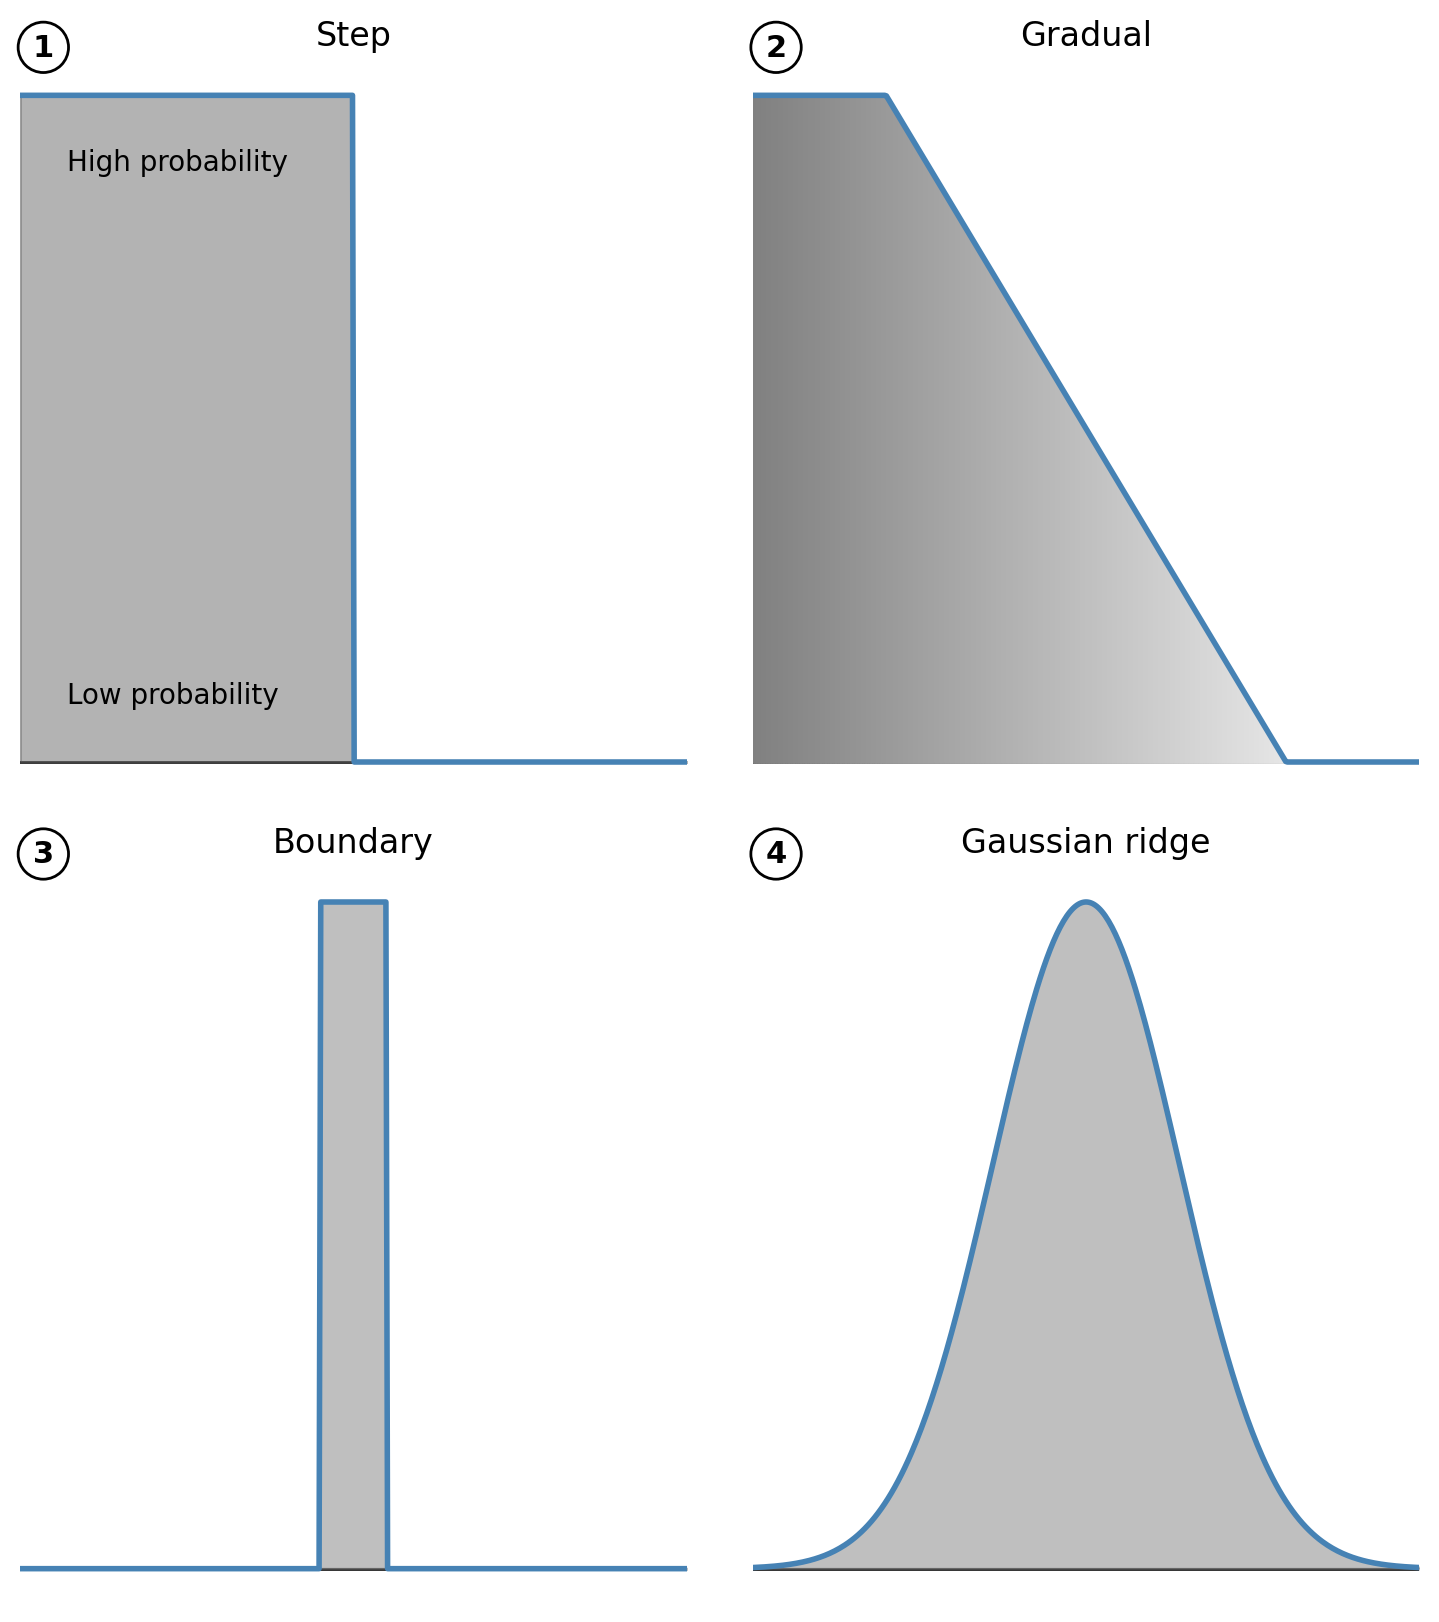

In [61]:
# Combined 2x2 plot: Step, Gradual, Boundary ridge, Gaussian ridge
x = np.linspace(0, 10, 400)
y_step = np.piecewise(x, [x < 5, x >= 5], [1, 0])
y_gradual = np.piecewise(
    x,
    [x <= 2, np.logical_and(x > 2, x < 8), x >= 8],
    [lambda x: 1, lambda x: 1 - (x - 2) / (8 - 2), lambda x: 0]
)

x_ridge = np.linspace(-5, 5, 400)
y_step_ridge = np.piecewise(
    x_ridge,
    [x_ridge < -0.5, (x_ridge >= -0.5) & (x_ridge <= 0.5), x_ridge > 0.5],
    [0, 1, 0]
)
sigma = 1.4
y_gauss = np.exp(-0.5 * (x_ridge / sigma) ** 2)
y_gauss = y_gauss / np.max(y_gauss)

fig, axs = plt.subplots(2, 2, figsize=(12, 10), dpi=200)
fig.subplots_adjust(hspace=0.1, wspace=-0.35)

plot_curve(
    axs[0, 0],
    x,
    y_step,
    'Step',
    fill_color='dimgray',
    show_labels=True,
    high_label='High probability',
    low_label='Low probability',
    subfigure_marker='1'
)
plot_curve(
    axs[0, 1],
    x,
    y_gradual,
    'Gradual',
    fill_color='grey',
    gradient=True,
    grad_high='white',
    subfigure_marker='2'
)
plot_curve(
    axs[1, 0],
    x_ridge,
    y_step_ridge,
    'Boundary',
    fill_color='gray',
    subfigure_marker='3'
)
plot_curve(
    axs[1, 1],
    x_ridge,
    y_gauss,
    'Gaussian ridge',
    fill_color='gray',
    subfigure_marker='4'
)

plt.show()

In [8]:
width = 1500
height = 1500
cutout_left = 1000
cutout_top = 500

vertices = [
    (0, height),
    (width, height),
    (width, cutout_top),
    (cutout_left, cutout_top),
    (cutout_left, 0),
    (0, 0)
]

edges = [
    [0, 1],
    [1, 2],
    [2, 3],
    [3, 4],
    [4, 5],
    [5, 0]
]


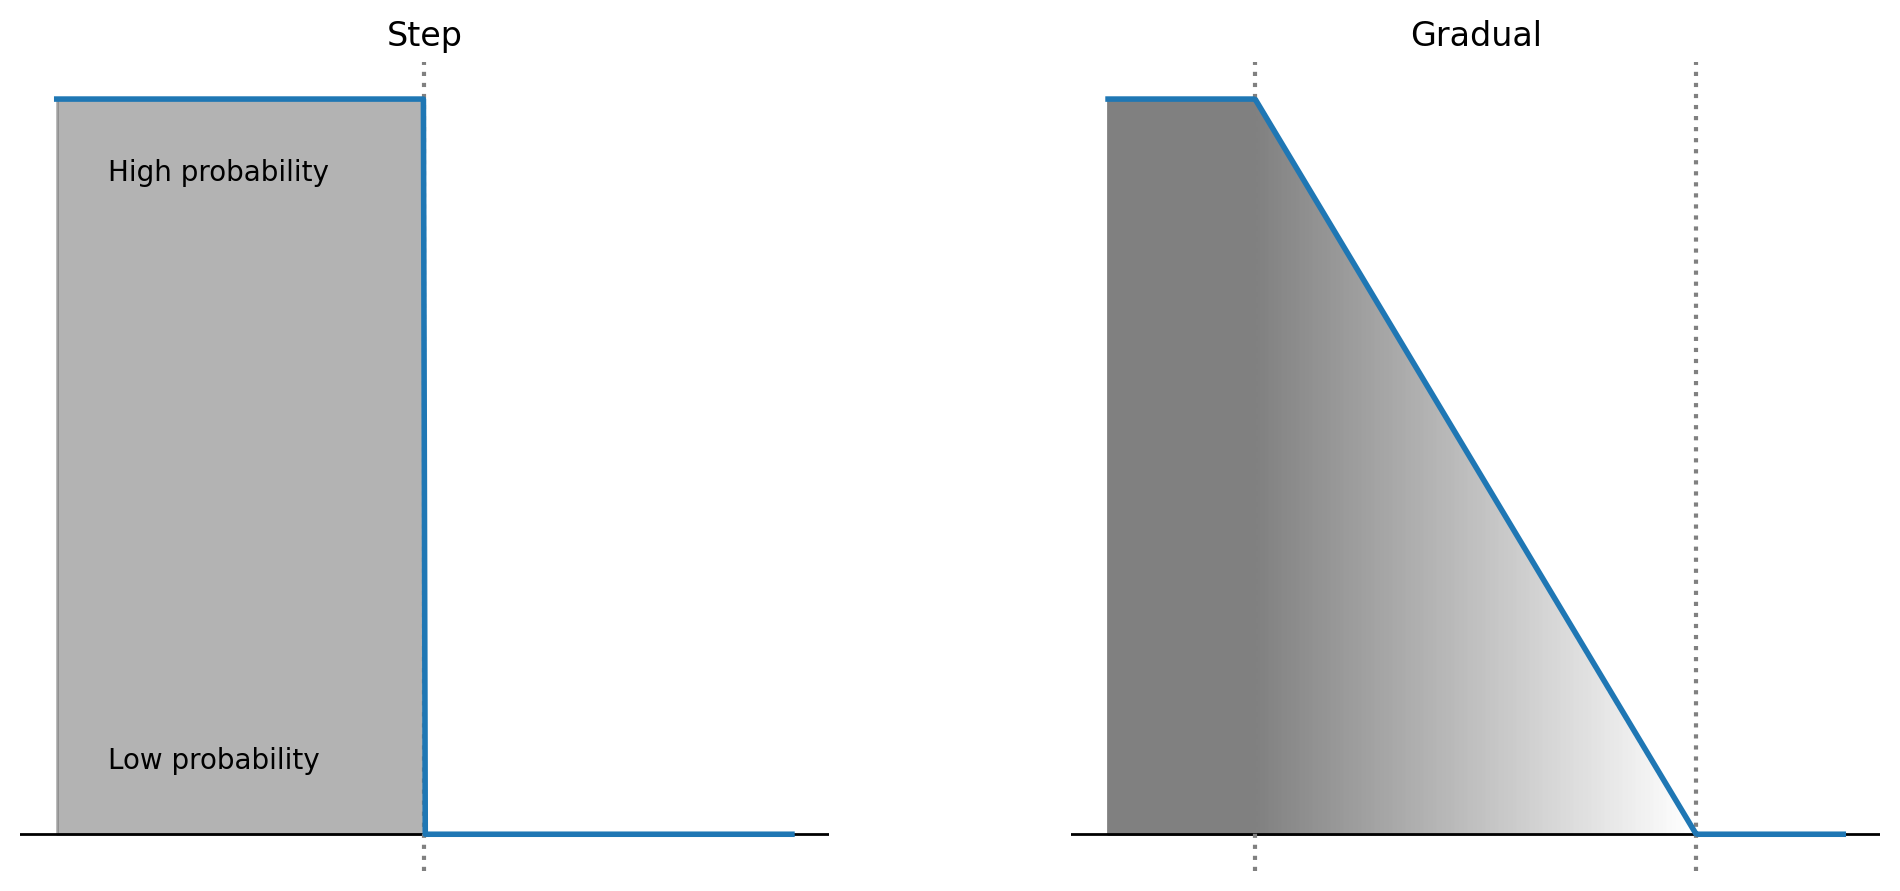

In [27]:
from matplotlib.patches import Polygon

# Generate a step data set, a gradient line dataset, a concave curve, and a convex curve
# From the same starting to end value
x = np.linspace(0, 10, 400)
y1 = np.piecewise(x, [x < 5, x >= 5], [1, 0])

# Make a graph that is 1 until x=2, then linearly decreases to 0 at x=8, then stays at 0
y2 = np.piecewise(
    x,
    [x <= 2, np.logical_and(x > 2, x < 8), x >= 8],
    [lambda x: 1, lambda x: 1 - (x - 2) / (8 - 2), lambda x: 0]
)

# Plot the datasets in a 2x2 grid with one empty subplot, and make each subplot square
fig, axs = plt.subplots(1, 2, figsize=(12, 6), dpi=200)
fig.subplots_adjust(hspace=0.4, wspace=0.3)
# Set square aspect ratio for each subplot, scaling y so 0-1 matches 0-10 in x
# Hide the X axis values for all subplots
for ax in axs.flat:
    ax.set_aspect(10, adjustable='box')
    ax.set_xticks([])
    ax.set_yticks([])
    for side in ['top', 'right', 'left', 'bottom']:
        ax.spines[side].set_visible(False)
    ax.axhline(0, color='black', linewidth=1)

# For the first plot, draw a vertical dashed line at x=5 to represent the step change
# then shade in dark grey the area under the step - ie 0, 0 to 0.5, 1.0.
axs[0].axvline(x=5, color='gray', linestyle='dotted')
axs[0].fill_betweenx(y=[0, 1], x1=0, x2=5, color='dimgray', alpha=0.5)

axs[0].plot(x, y1, label='Step', linewidth=2, antialiased=True)
axs[0].set_title('Step')
axs[0].tick_params(bottom=False, labelbottom=False, left=False, labelleft=False)
axs[0].text(0.7, 0.9, 'High probability', ha='left', va='center', fontsize=10)
axs[0].text(0.7, 0.1, 'Low probability', ha='left', va='center', fontsize=10)

# For the second plot, draw vertical bars at x=2 and x=8 to represent the start and end of the gradient
# and shade lightly between them to represent the area of change
axs[1].axvline(x=2, color='gray', linestyle='dotted')
axs[1].axvline(x=8, color='gray', linestyle='dotted')

axs[1].fill_betweenx(y=[0, 1], x1=0, x2=2, color="grey", alpha=1)
# Draw a gradient from grey to white as a shaded triangle between (2, 1) and (8, 0)

# Define triangle vertices: (2,1), (8,0), (2,0)
triangle = np.array([[2, 1], [8, 0], [2, 0]])

# Create a polygon patch
poly = Polygon(triangle, closed=True)

# Create a gradient color array from dark grey to white; stop a hair before x=8 to avoid touching the line
n_steps = 100
x_vals = np.linspace(1.95, 8 - 0.091, n_steps)
y_vals = np.linspace(1, 0, n_steps)
greys = np.linspace(0.5, 1, n_steps)
for i in range(n_steps - 1):
    # Interpolate y between 1 and 0
    y_top = y_vals[i]
    y_bot = 0
    axs[1].fill_betweenx(y=[0, y_top], x1=x_vals[i], x2=x_vals[i+1], color=(greys[i],) * 3, alpha=1)

axs[1].plot(x, y2, label='Gradual', antialiased=True, linewidth=2)
axs[1].set_title('Gradual')
axs[1].tick_params(bottom=False, labelbottom=False, left=False, labelleft=False)

plt.show()

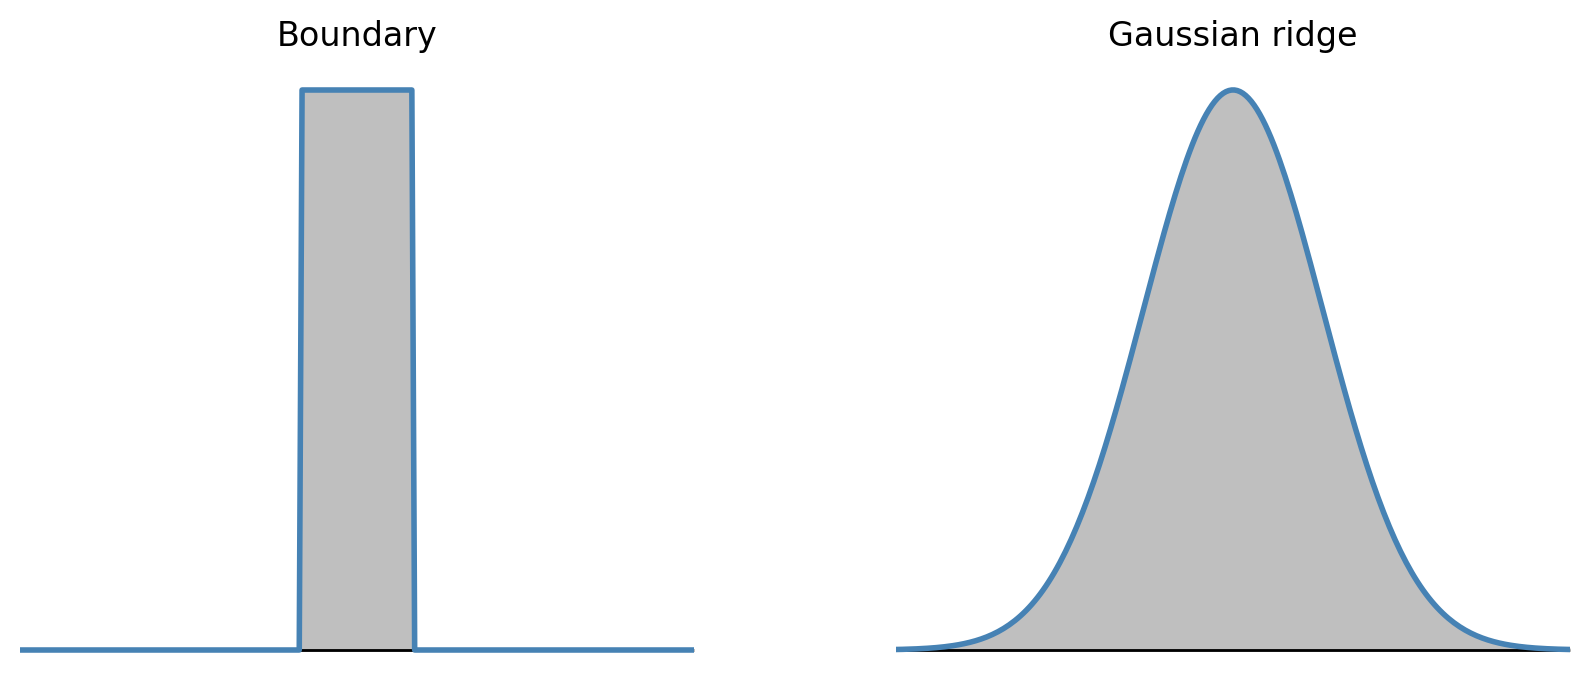

In [ ]:
# Step ridge vs Gaussian ridge
x = np.linspace(-5, 5, 400)

# Narrow step ridge: 0 -> 1 -> 0 centered at 0
y_step_ridge = np.piecewise(
    x,
    [x < -0.5, (x >= -0.5) & (x <= 0.5), x > 0.5],
    [0, 1, 0]
)

# Gaussian ridge flowing around the step
sigma = 2.0
y_gauss = np.exp(-0.5 * (x / sigma) ** 2)
y_gauss = y_gauss / np.max(y_gauss)

fig, axs = plt.subplots(1, 2, figsize=(10, 4), dpi=200)
fig.subplots_adjust(wspace=0.3)

# Boundary step
axs[0].fill_between(x, y_step_ridge, color='gray', alpha=0.5)
axs[0].axhline(0, color='black', linewidth=1)
axs[0].set_title('Boundary')
axs[0].set_ylim(-0.05, 1.05)
axs[0].set_xlim(-3, 3)
axs[0].set_xticks([])
axs[0].set_yticks([])
for side in ['top', 'right', 'left', 'bottom']:
    axs[0].spines[side].set_visible(False)
axs[0].plot(x, y_step_ridge, color='steelblue', linewidth=2)
axs[0].tick_params(bottom=False, labelbottom=False, left=False, labelleft=False)

# Gaussian ridge
axs[1].fill_between(x, y_gauss, color='gray', alpha=0.5)
axs[1].axhline(0, color='black', linewidth=1)
axs[1].set_title('Gaussian ridge')
axs[1].set_ylim(-0.05, 1.05)
axs[1].set_xlim(-3, 3)
axs[1].set_xticks([])
axs[1].set_yticks([])
for side in ['top', 'right', 'left', 'bottom']:
    axs[1].spines[side].set_visible(False)
axs[1].tick_params(bottom=False, labelbottom=False, left=False, labelleft=False)
axs[1].plot(x, y_gauss, color='steelblue', linewidth=2)

plt.show()

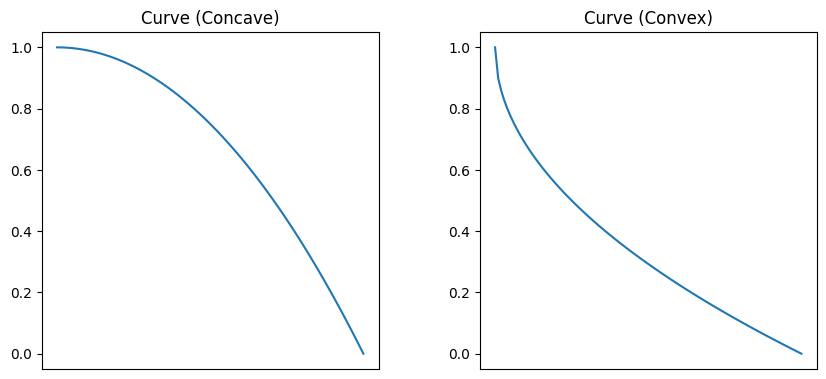

In [31]:
y3 = 1 - (x / max(x))**2
# Concave curve with greatest rate of change at start, least at end, from (0,0) to (10,1)
y4 = 1 - np.sqrt(x / max(x))
# Plot the datasets in a 2x2 grid with one empty subplot, and make each subplot square
fig, axs = plt.subplots(1, 2, figsize=(10, 10))
fig.subplots_adjust(hspace=0.4, wspace=0.3)

# Set square aspect ratio for each subplot, scaling y so 0-1 matches 0-10 in x
for ax in axs.flat:
    ax.set_aspect(10, adjustable='box')
    ax.set_xticks([])

axs[0].plot(x, y3, label='Curve')
axs[0].set_title('Curve (Concave)')

axs[1].plot(x, y4, label='Curve')
axs[1].set_title('Curve (Convex)')
plt.show()

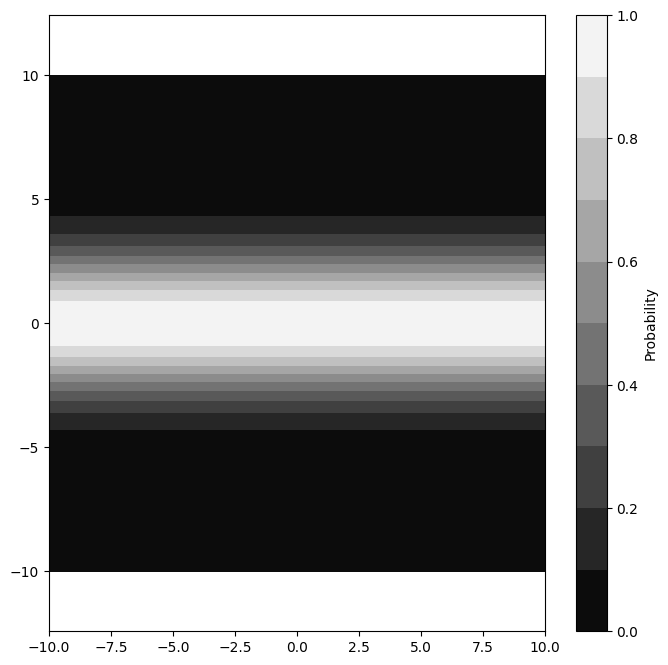

In [4]:
# Formulae - a horizontal line, at 0.
# With intensity 1 following the line, then dropping off smoothly to 0 above and below, over a distance of 8 units.
# The line spans about 20 units.
x = np.linspace(-10, 10, 400)
y = np.linspace(-10, 10, 400)
X, Y = np.meshgrid(x, y)
Z = np.exp(-((Y)**2) / (2 * (2**2)))
Z = Z / np.max(Z)  # Normalize to 0-1
plt.figure(figsize=(8, 8))
plt.contourf(X, Y, Z, levels=10, cmap='grey')
plt.colorbar(label='Probability')
# plt.title('Intensity around a Horizontal Line')
# plt.xlabel('X-axis')
# plt.ylabel('Y-axis')
plt.axis('equal')
plt.show()


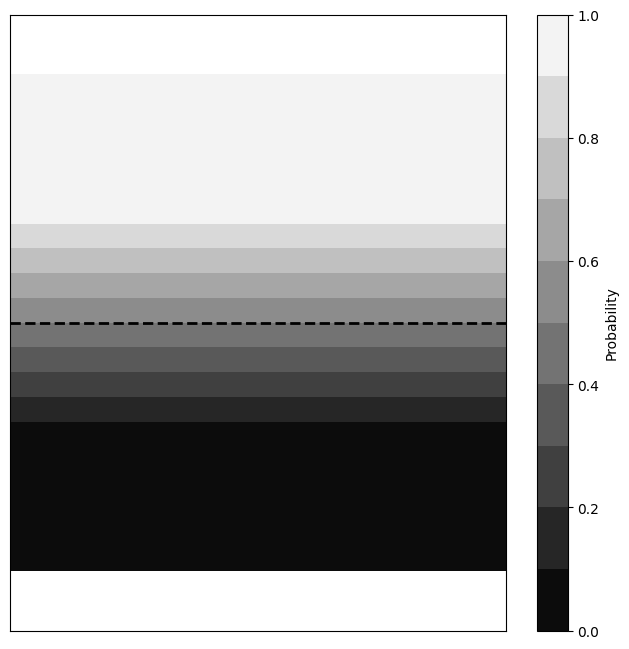

In [5]:
# Formulae - a horizontal line, at 0.
# With intensity 1 above the line, then dropping off smoothly to 0 below the line, with the line as a fuzzy boundary over a distance of 8 units.
# The line spans about 20 units.
x = np.linspace(-10, 10, 400)
y = np.linspace(-10, 10, 400)
X, Y = np.meshgrid(x, y)
# Use y2 to create a vertical transition along y, so Z is 1 above y=0, linearly decreases to 0 at y=-5, and 0 below
Z_profile = np.piecewise(
    y,
    [y >= 5, np.logical_and(y < 5, y > -5), y <= -5],
    [lambda y: 1, lambda y: (y + 5) / 10, lambda y: 0]
)
Z = np.tile(Z_profile, (X.shape[1], 1)).T


plt.figure(figsize=(8, 8))
plt.contourf(X, Y, Z, levels=10, cmap='grey')

# Add a horizontal line at y=0
plt.axhline(y=0, color='black', linestyle='dashed', linewidth=2)

plt.colorbar(label='Probability')
plt.axis('equal')
# Hide the axis values
plt.xticks([])
plt.yticks([])
plt.show()


In [7]:
margin = 100
# map x and map y are the map coordinates.
# A map is a view projected over a real world area. 
# The 0, 0 world x, y could be anywhere within the map.
mx_range = np.arange(-margin, width + margin)
my_range = np.arange(-margin, height + margin)
# Remember that the edges are all defined in world coordinates.

In [8]:
# Convert between our map representation, and the world coordinates relative to a zero
def world_to_map(wx, wy):
    mx = margin + wx
    my = margin + wy
    return mx, my

def map_to_world(mx, my):
    wx = mx - margin
    wy = my - margin
    return wx, wy
    

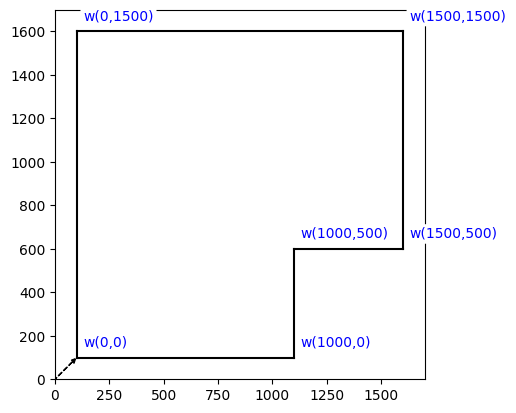

In [9]:
# Plot the edges of the arena, converting the coordinates as we go.
for edge in edges:
    v0 = vertices[edge[0]]
    v1 = vertices[edge[1]]
    mv0 = world_to_map(*v0)
    mv1 = world_to_map(*v1)
    plt.plot([mv0[0], mv1[0]], [mv0[1], mv1[1]], 'k-')
    # Label the starting vertices with their world coordinates
    plt.text(
        mv0[0] + 30, mv0[1] + 50,
        f"w({v0[0]},{v0[1]})",
        fontsize=10,
        color='blue',
        bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.2')
    )
# draw a dashed line from m(0,0) with arrow head to w(0,0) (margin, margin)
# plt.plot([margin, 0], [margin, 0], 'r--')
plt.arrow(0, 0, margin-20, margin-20, head_width=20, head_length=20, fc='k', ec='k', linestyle='dashed')


plt.xlim(0, width + 2 * margin)
plt.ylim(0, height + 2 * margin)
plt.gca().set_aspect('equal', adjustable='box')


In [7]:
mini_x_range = np.linspace(2, 5, num=4)
mini_y_range = np.linspace(10, 80, num=8)
mini_map_x, mini_map_y = np.meshgrid(mini_x_range, mini_y_range, indexing='xy')
mini_map_x, mini_map_y

(array([[2., 3., 4., 5.],
        [2., 3., 4., 5.],
        [2., 3., 4., 5.],
        [2., 3., 4., 5.],
        [2., 3., 4., 5.],
        [2., 3., 4., 5.],
        [2., 3., 4., 5.],
        [2., 3., 4., 5.]]),
 array([[10., 10., 10., 10.],
        [20., 20., 20., 20.],
        [30., 30., 30., 30.],
        [40., 40., 40., 40.],
        [50., 50., 50., 50.],
        [60., 60., 60., 60.],
        [70., 70., 70., 70.],
        [80., 80., 80., 80.]]))

In [9]:
mini_map_x[1,8], mini_map_y[1,8]

IndexError: index 8 is out of bounds for axis 1 with size 4

## Explaining meshgrid to myself

The numpy meshgrid appears to generate two arrays.
Each array is a 2D array, a grid of coordinates.
The first array contains the x-coordinates and the other contains the y-coordinates.

Let's create some ranges for x and y coordinates

In [11]:
mini_x_range = np.linspace(2, 5, num=4)
mini_y_range = np.linspace(10, 80, num=8)

When we create a meshgrid, we get two arrays.

The meshgrid is created from 2 1D arrays, one for the x-coordinates and one for the y-coordinates.
Indexing these arrays depends on how it was created - xy and ij.

## xy grid 
This eans that the first dimension corresponds to the y-coordinates and the second dimension corresponds to the x-coordinates

In [39]:
mini_map_xy_x, mini_map_xy_y = np.meshgrid(mini_x_range, mini_y_range, indexing='xy')
mini_map_xy_x, mini_map_xy_y

(array([[2., 3., 4., 5.],
        [2., 3., 4., 5.],
        [2., 3., 4., 5.],
        [2., 3., 4., 5.],
        [2., 3., 4., 5.],
        [2., 3., 4., 5.],
        [2., 3., 4., 5.],
        [2., 3., 4., 5.]]),
 array([[10., 10., 10., 10.],
        [20., 20., 20., 20.],
        [30., 30., 30., 30.],
        [40., 40., 40., 40.],
        [50., 50., 50., 50.],
        [60., 60., 60., 60.],
        [70., 70., 70., 70.],
        [80., 80., 80., 80.]]))

In [25]:
# So we can access the grid point for map x 3 and map y 7 at:
query_point_x = 3
query_point_y = 7
# This will cause an error - since the arrray is the other way around
mini_map_xy_x[query_point_x, query_point_y], mini_map_xy_y[query_point_x, query_point_y]

IndexError: index 7 is out of bounds for axis 1 with size 4

In [26]:
# But this works:
mini_map_xy_x[query_point_y, query_point_x], mini_map_xy_y[query_point_y, query_point_x]
# So with "indexing='xy'" the first index is the y value, the second index is the x value.

(np.float64(5.0), np.float64(80.0))

In [27]:
# What about with "ij" indexing?
mini_map_ij_x, mini_map_ij_y = np.meshgrid(mini_x_range, mini_y_range, indexing='ij')
mini_map_ij_x, mini_map_ij_y

(array([[2., 2., 2., 2., 2., 2., 2., 2.],
        [3., 3., 3., 3., 3., 3., 3., 3.],
        [4., 4., 4., 4., 4., 4., 4., 4.],
        [5., 5., 5., 5., 5., 5., 5., 5.]]),
 array([[10., 20., 30., 40., 50., 60., 70., 80.],
        [10., 20., 30., 40., 50., 60., 70., 80.],
        [10., 20., 30., 40., 50., 60., 70., 80.],
        [10., 20., 30., 40., 50., 60., 70., 80.]]))

In [28]:
# These arrays are now 4 rows (x values) by 8 columns (y values).
query_point_x = 3
query_point_y = 7
mini_map_ij_x[query_point_x, query_point_y], mini_map_ij_y[query_point_x, query_point_y]

(np.float64(5.0), np.float64(80.0))

In [29]:
# Accessing the other way - y,x causes an error
mini_map_ij_x[query_point_y, query_point_x], mini_map_ij_y[query_point_y, query_point_x]

IndexError: index 7 is out of bounds for axis 0 with size 4

## Broadcasting these

In numpy broadcasting means running a vecytorised operation on everye element of an array, when it's a single 1d or 2d array.
Let's do a simple broadcasting operation to ensure we have this:

In [45]:
broadcast_test_1d_array = np.array([1, 2, 3, 4, 5])
# Multiply by 5, mask even
broadcast_test_1d_array * 5, broadcast_test_1d_array % 2 == 0

(array([ 5, 10, 15, 20, 25]), array([False,  True, False,  True, False]))

Ok, so that's 1d broadcasting. 2d broadcasting is going to be quite similar

In [46]:
broadcast_2d_test_array = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])
# Multiply by 10, mask even
broadcast_2d_test_array * 10, broadcast_2d_test_array % 2 == 0

(array([[10, 20, 30],
        [40, 50, 60],
        [70, 80, 90]]),
 array([[False,  True, False],
        [ True, False,  True],
        [False,  True, False]]))

A single meshgrid coordinate array is simply a 2d array:

In [47]:
(mini_map_xy_x >= 3) & (mini_map_xy_x < 5)

array([[False,  True,  True, False],
       [False,  True,  True, False],
       [False,  True,  True, False],
       [False,  True,  True, False],
       [False,  True,  True, False],
       [False,  True,  True, False],
       [False,  True,  True, False],
       [False,  True,  True, False]])

In [48]:
# With ij
(mini_map_ij_x >= 3) & (mini_map_ij_x < 5)

array([[False, False, False, False, False, False, False, False],
       [ True,  True,  True,  True,  True,  True,  True,  True],
       [ True,  True,  True,  True,  True,  True,  True,  True],
       [False, False, False, False, False, False, False, False]])

In [49]:
# We can combine results with the same shape easily
# Think of each operation as generating a mask, then combining the masks with AND (&) or OR (|)
(mini_map_xy_x >= 3) & (mini_map_xy_x < 5) & (mini_map_xy_y > 30) & (mini_map_xy_y < 70)
# The result array has the same shape as the input arrays

array([[False, False, False, False],
       [False, False, False, False],
       [False, False, False, False],
       [False,  True,  True, False],
       [False,  True,  True, False],
       [False,  True,  True, False],
       [False, False, False, False],
       [False, False, False, False]])

I see it. 
The fundamental mismatch.
An image for plotting - wants rows (indexed by Y) first, then columns (indexed by X)
However, for us to use [x,y] coordinates, we want columns by X first, then Y.

So...
Generate as we'd want to index it using IJ.
Then Use .T to transpose when drawing?

Works perfectly.

Can I explain transposing a matrix.

A matrix has rows and colums.

The transpose is an operation where rows and columns are swapped.